# 🌳 Decision Tree Classification

## 🎯 Learning Objectives

After completing this notebook, you will be able to:

- Understand Decision Tree Classification.
- Learn how a Decision Tree makes decisions.
- Understand Gini Impurity and Entropy.
- Learn Information Gain.
- Understand Tree Pruning.
- Build and evaluate a Decision Tree Classifier.

## 📖 Introduction

Decision Tree Classification is a supervised learning algorithm used to classify data into different categories.

It works by repeatedly splitting the dataset into smaller subsets based on the feature that best separates the classes.

The result is a tree-like structure where each internal node represents a decision, each branch represents an outcome, and each leaf node represents a predicted class.

## ❓ What is a Decision Tree?

A Decision Tree predicts the class of a sample by asking a sequence of questions.

Each question splits the data into smaller groups until a final decision (class) is reached.## 🌍 Real-Life Intuition

Imagine deciding whether to play cricket.

Question 1:

Is it raining?

↓

Yes → Stay home

No →

Question 2:

Is the ground dry?

↓

Yes → Play cricket

No → Wait

A Decision Tree works in exactly the same way by asking a sequence of questions.

## 🌳 Decision Tree Terminology

### Root Node

The first node where the initial split occurs.

---

### Internal Node

A decision point where the data is split again.

---

### Leaf Node

The final node containing the predicted class.

---

### Branch

The connection between nodes representing a decision outcome.

## 📊 Gini Impurity

Gini Impurity measures how mixed the classes are after a split.

- Lower Gini → Better split
- Higher Gini → Poor split

Range:

- 0 → Pure node
- 0.5 → Mixed node (binary classification)

## 📈 Entropy

Entropy measures the randomness or uncertainty in the data.

- Entropy = 0 → Pure node
- Higher entropy → More uncertainty

The Decision Tree chooses splits that reduce entropy.

## ⭐ Information Gain

Information Gain measures how much uncertainty decreases after a split.

Higher Information Gain means a better split.

The feature with the highest Information Gain is selected for splitting.

## 📊 Gini vs Entropy

| Gini Impurity | Entropy |
|--------------|---------|
| Faster to compute | Slightly slower |
| Default in Scikit-learn | Information theory based |
| Often produces similar trees | Often produces similar trees |

## ✂️ Tree Pruning

Decision Trees can grow very deep and memorize the training data.

Pruning removes unnecessary branches to reduce overfitting and improve generalization.

## ✅ Advantages

- Easy to understand
- Easy to visualize
- Handles nonlinear relationships
- Requires little data preparation
- No feature scaling required

## ❌ Disadvantages

- Can overfit easily
- Sensitive to small data changes
- Lower accuracy than ensemble methods

## 🌍 Applications

- Medical Diagnosis
- Fraud Detection
- Credit Approval
- Customer Churn Prediction
- Risk Assessment

In [1]:
import pandas as pd

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

import matplotlib.pyplot as plt

In [2]:
data = load_breast_cancer()

X = pd.DataFrame(
    data.data,
    columns=data.feature_names
)

y = data.target

In [3]:
X.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [4]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 30 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [6]:
model = DecisionTreeClassifier(
    criterion="gini",
    random_state=42
)

In [7]:
model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [8]:
y_pred = model.predict(X_test)

In [9]:
print("Accuracy :", accuracy_score(y_test, y_pred))

Accuracy : 0.9122807017543859


In [10]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[39  3]
 [ 7 65]]


In [11]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.85      0.93      0.89        42
           1       0.96      0.90      0.93        72

    accuracy                           0.91       114
   macro avg       0.90      0.92      0.91       114
weighted avg       0.92      0.91      0.91       114



In [12]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

importance.sort_values(
    by="Importance",
    ascending=False
)

,Feature,Importance
20,worst radius,0.697811
27,worst concave points,0.116083
21,worst texture,0.058881
11,texture error,0.052661
26,worst concavity,0.016325
23,worst area,0.012678
13,area error,0.012085
28,worst symmetry,0.010733
24,worst smoothness,0.008452
17,concave points error,0.006261


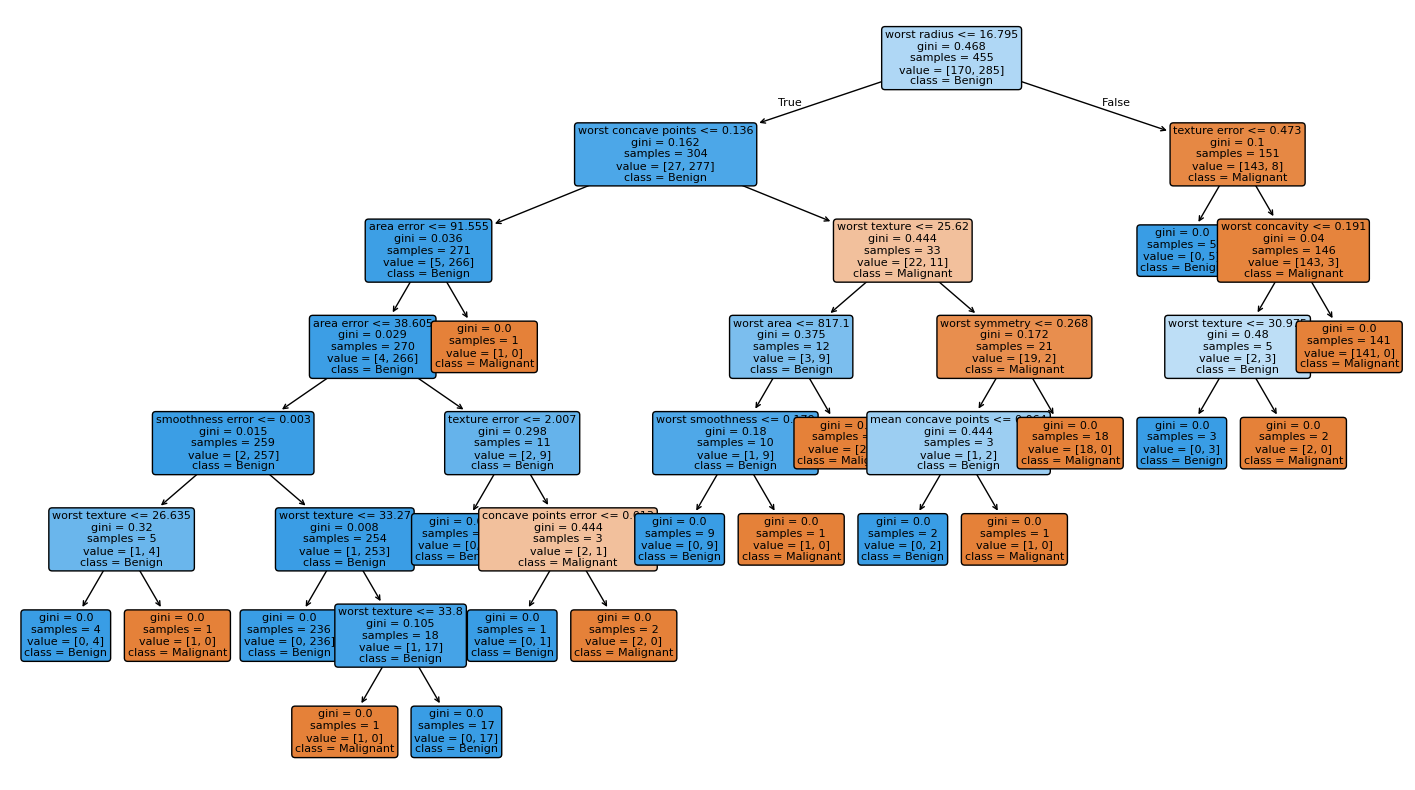

In [13]:
plt.figure(figsize=(18,10))

plot_tree(
    model,
    feature_names=X.columns,
    class_names=["Malignant","Benign"],
    filled=True,
    rounded=True,
    fontsize=8
)

plt.show()

In [14]:
entropy_model = DecisionTreeClassifier(
    criterion="entropy",
    random_state=42
)

entropy_model.fit(X_train, y_train)

print(
    "Entropy Accuracy:",
    accuracy_score(
        y_test,
        entropy_model.predict(X_test)
    )
)

Entropy Accuracy: 0.9122807017543859


## ⚙️ Hyperparameters

### criterion

- gini
- entropy

---

### max_depth

Maximum depth of the tree.

---

### min_samples_split

Minimum samples required before splitting.

---

### min_samples_leaf

Minimum samples required in a leaf node.

---

### max_features

Number of features considered for each split.

## ⚠️ Common Mistakes

- Growing very deep trees.
- Ignoring overfitting.
- Not tuning max_depth.
- Evaluating only training accuracy.

## ✅ Best Practices

- Limit tree depth.
- Use pruning.
- Compare Gini and Entropy.
- Compare with Random Forest.

## 📝 Summary

Decision Trees classify data by repeatedly splitting it based on the most informative features. They are simple, interpretable, and form the basis of many advanced ensemble learning algorithms such as Random Forest and XGBoost.